# 2 Learning from data

# Generate data

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Generate 100 samples
n_samples = 100

# Generate X values (uniformly distributed between 0 and 10)
X = 10 * np.random.rand(n_samples, 1)

# Generate epsilon values (normally distributed with mean 0 and standard deviation 15)
epsilon = np.random.normal(0, 15, n_samples)

# Generate Y values using the model Y = 3 + 2X + epsilon
Y = 3 + 2 * X + epsilon[:, np.newaxis]

# Plot

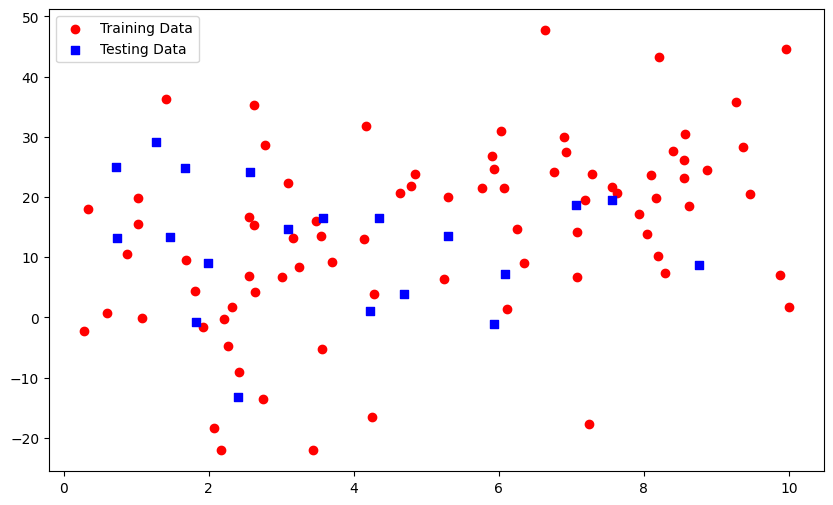

In [2]:
r = np.random.randint(104)

# Split the data into training and test sets (80% train, 20% test)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=r)

# Plot the data points
plt.figure(figsize=(10, 6))
plt.scatter(X_train, Y_train, alpha=1, marker='o', color='red', label='Training Data')
plt.scatter(X_test, Y_test, alpha=1, marker='s', color='blue', label='Testing Data')
plt.legend()
plt.show()

# Run multiple time

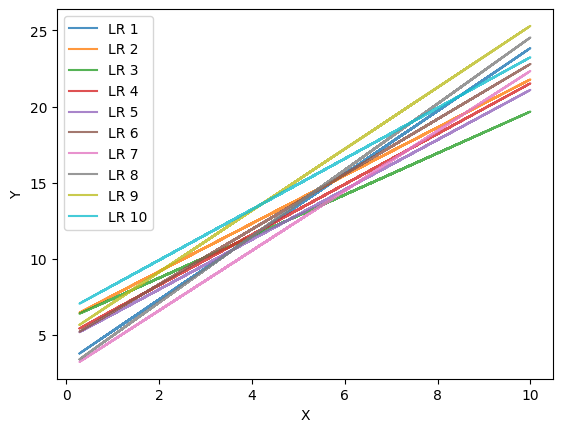

In [3]:
for i in range(10):
    r = np.random.randint(104)
    X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=r)

    # Perform linear regression
    model = LinearRegression()
    model.fit(X_train, Y_train)

    # Predict Y values using the model
    Y_pred = model.predict(X)

    # Plot the regression line
    plt.plot(X, Y_pred, label=f'LR {i + 1}', alpha=0.8)

# Customize the plot
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

# Data samples to 10,000

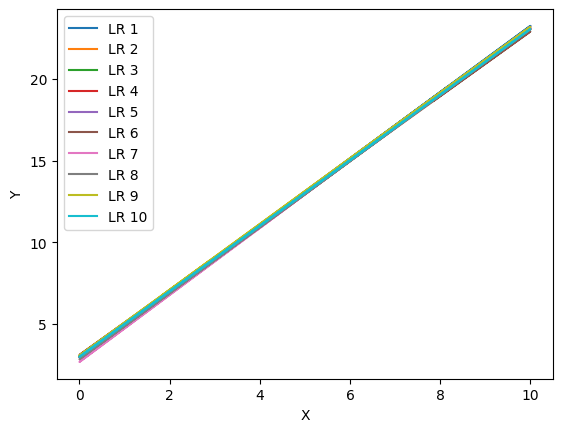

In [4]:
# Generate 100 samples
n_samples = 10000

# Generate X values (uniformly distributed between 0 and 10)
X = 10 * np.random.rand(n_samples, 1)

# Generate epsilon values (normally distributed with mean 0 and standard deviation 15)
epsilon = np.random.normal(0, 15, n_samples)

# Generate Y values using the model Y = 3 + 2X + epsilon
Y = 3 + 2 * X + epsilon[:, np.newaxis]

# Plotting 10 different instances
for i in range(10):
    # Split the data into training and testing sets
    X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=np.random.randint(104))

    # Perform linear regression
    model = LinearRegression()
    model.fit(X_train, Y_train)

    # Predict Y values using the model on the training data
    Y_pred_train = model.predict(X_train)

    # Plot the regression line for the training data
    plt.plot(X_train, Y_pred_train, label=f'LR {i+1}')

# Customize the plot
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

# 3. Linear regression on real world data

# Install `ucimlrepo`

In [5]:
!pip install ucimlrepo

# Import necessary libraries

In [6]:
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import pandas as pd

# Load Data

In [7]:
# Fetch the dataset
infrared_thermography_temperature = fetch_ucirepo(id=925)

# Data (as pandas dataframes)
X = infrared_thermography_temperature.data.features
y = infrared_thermography_temperature.data.targets

# Metadata
print(infrared_thermography_temperature.metadata)

# Variable information
print(infrared_thermography_temperature.variables)

{'uci_id': 925, 'name': 'Infrared Thermography Temperature', 'repository_url': 'https://archive.ics.uci.edu/dataset/925/infrared+thermography+temperature+dataset', 'data_url': 'https://archive.ics.uci.edu/static/public/925/data.csv', 'abstract': 'The Infrared Thermography Temperature Dataset contains temperatures read from various locations of inferred images about patients, with the addition of oral temperatures measured for each individual. The 33 features consist of gender, age, ethnicity, ambiant temperature, humidity, distance, and other temperature readings from the thermal images. The dataset is intended to be used in a regression task to predict the oral temperature using the environment information as well as the thermal image readings. ', 'area': 'Health and Medicine', 'tasks': ['Regression'], 'characteristics': ['Tabular'], 'num_instances': 1020, 'num_features': 33, 'feature_types': ['Real', 'Categorical'], 'demographics': ['Gender', 'Age', 'Ethnicity'], 'target_col': ['aveO

# No Dep. variables & Indep. variables

In [8]:
# Number of independent variables (features)
print(f"Number of Independent Variables: {X.shape[1]}")

# Number of categorical features
num_categorical = X.select_dtypes(include=['object', 'category']).shape[1]
print(f"Number of Categorical Features: {num_categorical}")

# Number of continuous features
num_continuous = X.select_dtypes(include=['number']).shape[1]
print(f"Number of Continuous Features: {num_continuous}")

# Number of dependent variables (targets)
print(f"Number of Dependent Variables: {y.shape[1]}")

# Print the names of dependent variables
print(f"Dependent Variables: {', '.join(y.columns)}")

Number of Independent Variables: 33
Number of Categorical Features: 3
Number of Continuous Features: 30
Number of Dependent Variables: 2
Dependent Variables: aveOralF, aveOralM


# Select dependent feature and independent features

In [9]:
# Select 'aveOralM' as the dependent variable
# Checking if 'aveOralM' is present in the target columns
y_selected = y['aveOralM']

# Select independent features - Age and four other features
# I have chosen 'T_atm', 'Humidity', 'Distance', and 'T_RC_Max1' as additional features based on general relevance.
selected_features = ['Age', 'T_atm', 'Humidity', 'Distance', 'T_RC_Max1']

# Create a new DataFrame with the selected independent features
X_selected = X[selected_features]

# Display the selected features and the target variable
print("Selected Independent Features:")
print(X_selected.head())

print("\nSelected Dependent Feature (aveOralM):")
print(y_selected.head())

Selected Independent Features:
     Age  T_atm  Humidity  Distance  T_RC_Max1
0  41-50   24.0      28.0       0.8    35.0325
1  31-40   24.0      26.0       0.8    34.7425
2  21-30   24.0      26.0       0.8    35.7175
3  21-30   24.0      27.0       0.8    35.2250
4  18-20   24.0      27.0       0.8    35.6400

Selected Dependent Feature (aveOralM):
0    36.59
1    37.19
2    37.34
3    37.09
4    37.04
Name: aveOralM, dtype: float64


# Hot encode the categorical feature

In [10]:
# Assume X_cleaned is the DataFrame with the selected features, including the 'Age' feature
# Display the first few rows of the data before encoding (optional)
print("Before Encoding:")
print(X_selected.head())

# Perform one-hot encoding on the 'Age' feature
X_encoded = pd.get_dummies(X_selected, columns=['Age'], drop_first=True)  # drop_first=True to avoid multicollinearity

# Display the first few rows of the data after encoding
print("\nAfter One-Hot Encoding:")
print(X_encoded.head())

Before Encoding:
     Age  T_atm  Humidity  Distance  T_RC_Max1
0  41-50   24.0      28.0       0.8    35.0325
1  31-40   24.0      26.0       0.8    34.7425
2  21-30   24.0      26.0       0.8    35.7175
3  21-30   24.0      27.0       0.8    35.2250
4  18-20   24.0      27.0       0.8    35.6400

After One-Hot Encoding:
   T_atm  Humidity  Distance  T_RC_Max1  Age_21-25  Age_21-30  Age_26-30  \
0   24.0      28.0       0.8    35.0325      False      False      False   
1   24.0      26.0       0.8    34.7425      False      False      False   
2   24.0      26.0       0.8    35.7175      False       True      False   
3   24.0      27.0       0.8    35.2250      False       True      False   
4   24.0      27.0       0.8    35.6400      False      False      False   

   Age_31-40  Age_41-50  Age_51-60  Age_>60  
0      False       True      False    False  
1       True      False      False    False  
2      False      False      False    False  
3      False      False      False 

# Drop missing values

In [11]:
# Combine X_train and y_train to drop NaNs together
Data_before_clean = pd.concat([X_encoded, y_selected], axis=1)

# Drop rows with any NaN values
Data_after_clean = Data_before_clean.dropna()

# Separate X_train and y_train again
X_encoded = Data_after_clean.iloc[:, :-1]
y_selected = Data_after_clean.iloc[:, -1]

# Split the data into training (80%) and testing (20%)

In [12]:
# Split data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_selected, test_size=0.2, random_state=42)

# Print the shapes of the split datasets
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (814, 11)
X_test shape: (204, 11)
y_train shape: (814,)
y_test shape: (204,)


# Check `X_train.head()`

In [13]:
X_train.head()

,T_atm,Humidity,Distance,T_RC_Max1,Age_21-25,Age_21-30,Age_26-30,Age_31-40,Age_41-50,Age_51-60,Age_>60
137,24.1,25.9,0.79,35.7600,True,False,False,False,False,False,False
780,24.7,45.2,0.60,35.3000,False,False,False,False,False,False,False
754,24.1,41.3,0.60,36.6875,True,False,False,False,False,False,False
289,24.8,34.7,0.74,35.3950,False,False,False,False,False,False,False
899,23.9,15.3,0.65,35.3850,True,False,False,False,False,False,False


# Train a linear regression model

In [14]:
# Initialize the Linear Regression model
model = LinearRegression()

# Train the model with the training data
model.fit(X_train, y_train)

# Get the estimated coefficients
coefficients = model.coef_

# List of feature names after encoding
feature_names = X_train.columns

# Display the coefficients with corresponding feature names
coefficients_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})

# Print the estimated coefficients
print("Estimated Coefficients:")
print(coefficients_df.sort_values(by='Coefficient', ascending=False))

Estimated Coefficients:
      Feature  Coefficient
3   T_RC_Max1     0.765347
10    Age_>60     0.691407
8   Age_41-50     0.243059
5   Age_21-30     0.167224
9   Age_51-60     0.104276
6   Age_26-30     0.059082
4   Age_21-25     0.047461
7   Age_31-40     0.009003
2    Distance     0.002541
1    Humidity     0.001499
0       T_atm    -0.053396


# Do the same process for ``T_OR1``, ``T_OR_Max1``, ``T_FHC_Max1``, ``T_FH_Max1`` features as independent features

In [15]:
# If package not installed, install it using: pip install ucimlrepo
from ucimlrepo import fetch_ucirepo

# Fetch the dataset
infrared_thermography_temperature = fetch_ucirepo(id=925)

# Data (as pandas dataframes)
X = infrared_thermography_temperature.data.features
y = infrared_thermography_temperature.data.targets

# Metadata
print(infrared_thermography_temperature.metadata)

# Variable information
print(infrared_thermography_temperature.variables)

{'uci_id': 925, 'name': 'Infrared Thermography Temperature', 'repository_url': 'https://archive.ics.uci.edu/dataset/925/infrared+thermography+temperature+dataset', 'data_url': 'https://archive.ics.uci.edu/static/public/925/data.csv', 'abstract': 'The Infrared Thermography Temperature Dataset contains temperatures read from various locations of inferred images about patients, with the addition of oral temperatures measured for each individual. The 33 features consist of gender, age, ethnicity, ambiant temperature, humidity, distance, and other temperature readings from the thermal images. The dataset is intended to be used in a regression task to predict the oral temperature using the environment information as well as the thermal image readings. ', 'area': 'Health and Medicine', 'tasks': ['Regression'], 'characteristics': ['Tabular'], 'num_instances': 1020, 'num_features': 33, 'feature_types': ['Real', 'Categorical'], 'demographics': ['Gender', 'Age', 'Ethnicity'], 'target_col': ['aveO

In [16]:
# Number of independent variables (features)
print(f"Number of Independent Variables: {X.shape[1]}")

# Number of dependent variables (targets)
print(f"Number of Dependent Variables: {y.shape[1]}")

Number of Independent Variables: 33
Number of Dependent Variables: 2


In [17]:
# Select 'aveOralM' as the dependent variable
y_selected = y['aveOralM']

# I have chosen 'T_atm', 'Humidity', 'Distance', and 'T_RC_Max1' as additional features based on general relevance.
selected_features = ['T_OR1', 'T_OR_Max1', 'T_FHC_Max1', 'T_FH_Max1']

# Create a new DataFrame with the selected independent features
X_selected = X[selected_features]

# Display the selected features and the target variable
print("Selected Independent Features:")
print(X_selected.head())

print("\nSelected Dependent Feature (aveOralM):")
print(y_selected.head())

Selected Independent Features:
     T_OR1  T_OR_Max1  T_FHC_Max1  T_FH_Max1
0  35.6350    35.6525     34.0075    34.5300
1  35.0925    35.1075     34.6600    34.6825
2  35.8600    35.8850     35.2225    35.3450
3  34.9650    34.9825     35.3150    35.6025
4  35.5875    35.6175     35.3725    35.4175

Selected Dependent Feature (aveOralM):
0    36.59
1    37.19
2    37.34
3    37.09
4    37.04
Name: aveOralM, dtype: float64


In [18]:
# Display the first few rows of the data before encoding (optional)
print("Before Encoding:")
print(X_selected.head())

# Perform one-hot encoding on the 'Age' feature
X_encoded = pd.get_dummies(X_selected, drop_first=True)  # drop_first=True to avoid multicollinearity

# Fill NaN values with 0 (or another appropriate value)
X_encoded = X_encoded.fillna(0)

# Convert the boolean values (True/False) to integers (1/0)
X_encoded = X_encoded.astype(int)

# Display the first few rows of the data after encoding
print("\nAfter One-Hot Encoding:")
print(X_encoded.head())

Before Encoding:
     T_OR1  T_OR_Max1  T_FHC_Max1  T_FH_Max1
0  35.6350    35.6525     34.0075    34.5300
1  35.0925    35.1075     34.6600    34.6825
2  35.8600    35.8850     35.2225    35.3450
3  34.9650    34.9825     35.3150    35.6025
4  35.5875    35.6175     35.3725    35.4175

After One-Hot Encoding:
   T_OR1  T_OR_Max1  T_FHC_Max1  T_FH_Max1
0     35         35          34         34
1     35         35          34         34
2     35         35          35         35
3     34         34          35         35
4     35         35          35         35


In [19]:
# Combine X_train and y_train to drop NaNs together
Data_before_clean = pd.concat([X_encoded, y_selected], axis=1)

# Drop rows with any NaN values
Data_after_clean = Data_before_clean.dropna()

# Separate X_train and y_train again
X_encoded = Data_after_clean.iloc[:, :-1]
y_selected = Data_after_clean.iloc[:, -1]

In [20]:
from sklearn.model_selection import train_test_split

# Split data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_selected, test_size=0.2, random_state=42)

# Print the shapes of the split datasets
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (816, 4)
X_test shape: (204, 4)
y_train shape: (816,)
y_test shape: (204,)


In [21]:
X_train.head()

,T_OR1,T_OR_Max1,T_FHC_Max1,T_FH_Max1
743,35,35,35,35
137,35,36,34,34
799,37,37,37,38
933,36,37,35,36
822,35,35,34,35


In [22]:
# Import necessary libraries
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import pandas as pd

# Initialize the Linear Regression model
model = LinearRegression()

# Train the model with the training data
model.fit(X_train, y_train)

# Get the estimated coefficients
coefficients = model.coef_

# List of feature names after encoding
feature_names = X_train.columns

# Display the coefficients with corresponding feature names
coefficients_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})

# Print the estimated coefficients
print("Estimated Coefficients:")
print(coefficients_df.sort_values(by='Coefficient', ascending=False))

Estimated Coefficients:
      Feature  Coefficient
0       T_OR1     0.329928
3   T_FH_Max1     0.220438
1   T_OR_Max1     0.108462
2  T_FHC_Max1     0.085659


In [23]:
import statsmodels.api as sm

# Add a constant column to the feature matrix (required by statsmodels)
X_train_with_constant = sm.add_constant(X_train)

# Fit the OLS (Ordinary Least Squares) model
ols_model = sm.OLS(y_train, X_train_with_constant).fit()

# Get summary statistics of the model
summary = ols_model.summary()

# Print the summary
print(summary)

                            OLS Regression Results                            
Dep. Variable:               aveOralM   R-squared:                       0.555
Model:                            OLS   Adj. R-squared:                  0.552
Method:                 Least Squares   F-statistic:                     252.4
Date:                Tue, 10 Sep 2024   Prob (F-statistic):          8.85e-141
Time:                        14:39:34   Log-Likelihood:                -296.01
No. Observations:                 816   AIC:                             602.0
Df Residuals:                     811   BIC:                             625.5
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         10.8908      0.840     12.964      0.0

In [24]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from scipy import stats

# Fit the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict using the train set
y_pred = model.predict(X_train)

# Residuals
residuals = y_train - y_pred

# 1. Residual Sum of Squares (RSS)
RSS = np.sum(residuals ** 2)

# 2. Mean Squared Error (MSE)
MSE = mean_squared_error(y_train, y_pred)

# 3. R-squared (R²)
R_squared = r2_score(y_train, y_pred)

# 4. Residual Standard Error (RSE)
N = len(y_train)  # Total number of data samples
d = X_train.shape[1]  # Number of independent features
RSE = np.sqrt(RSS / (N - d - 1))

# Print the calculated metrics
print(f"Residual Standard Error (RSE): {RSE}")
print(f"Residual Sum of Squares (RSS): {RSS}")
print(f"Mean Squared Error (MSE): {MSE}")
print(f"R-squared (R²): {R_squared}")

Residual Standard Error (RSE): 0.34885285890422885
Residual Sum of Squares (RSS): 98.69733522134523
Mean Squared Error (MSE): 0.12095261669282503
R-squared (R²): 0.5545367157143727
